# Example plots

Training was performed using number of [training, validation, test] images:

- training-14 Dark images [100, 32, 30]
- training-15 (day)Light images [100, 32, 30]
- training-16 Mixed data: Light + Dark images, both [100, 32, 30] --> [200, 64, 60]
- training-18 Mixed data: Light + Dark images, both [50, 32, 30] --> [100, 32, 30]

## Plotting annotated images

We created some plotting functions in the module "vis.py" which we will use. If you want to change the colors/style of the rectangular boxes, please adapt that file.
Change the base_folder to match the one on your pc.

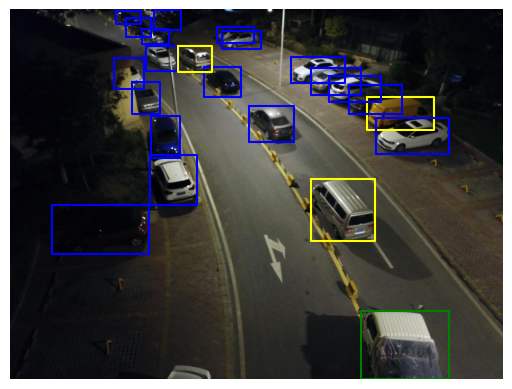

In [35]:
from pathlib import Path
%matplotlib inline
from importlib import reload  # Python 3.4+
import vis
vis = reload(vis)


# example (dark) image
base_folder = Path("./data/visdrone/det")
image_folder = base_folder / "dark" / "images"
label_folder = base_folder / "dark" / "labels"
# Night
img_id = "9999960_00000_d_0000037"
img_path = (image_folder / f"{img_id}.jpg").as_posix()
label_path = (label_folder / f"{img_id}.txt").as_posix()
fig_night = vis.show_labeled_img(img_path, label_path)


## Annotation vs. Prediction of labels

To show some representative example predictions, we can compare the predictions from the trained model with the original annotation (using the test data).



image 1/1 /home/mbarbier/Documents/prog/derin-car-tracking/data/visdrone/det/dark/images/9999960_00000_d_0000023.jpg: 480x640 4 pedestrians, 33 cars, 3 vans, 172.9ms
Speed: 1.6ms preprocess, 172.9ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /home/mbarbier/Documents/prog/derin-car-tracking/runs/detect/predict-8
1 label saved to /home/mbarbier/Documents/prog/derin-car-tracking/runs/detect/predict-8/labels


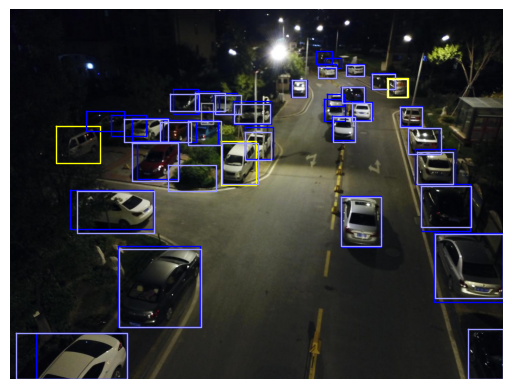

In [36]:
from pathlib import Path
from ultralytics import YOLO
%matplotlib inline
from importlib import reload  # Python 3.4+
import vis
vis = reload(vis)


# example (dark) image
base_folder = Path("./data/visdrone/det")
image_folder = base_folder / "dark" / "images"
label_folder = base_folder / "dark" / "labels"
pred_folder = Path("./runs/detect/predict") / "labels"
# Night
img_id = "9999960_00000_d_0000023"
img_path = (image_folder / f"{img_id}.jpg").as_posix()
label_path = (label_folder / f"{img_id}.txt").as_posix()
pred_path = (pred_folder / f"{img_id}.txt").as_posix()

# Run inference on an image
model = YOLO("runs/detect/train-14/weights/best.pt")  # load pretrained model
results = model(img_path, save_txt=True)
fig_night = vis.show_pred_img(img_path, label_path, pred_path)



## Plotting error metrics from YOLO

YOLO provides some standard error metrics. Some metrics are calculated for every epoch during training, we can plot and compare these metrics for different data: dark, light, mixed lighting conditions.

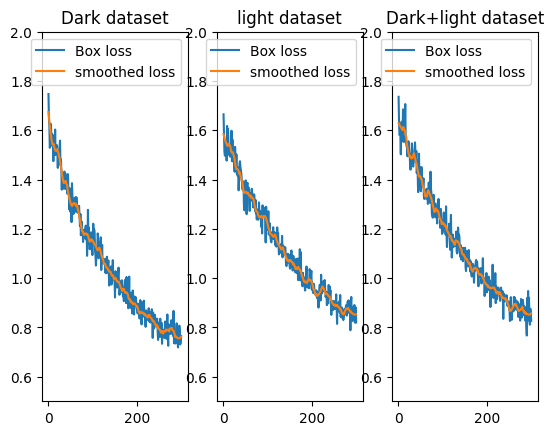

In [37]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics.utils.plotting import plot_results
from scipy.signal import savgol_filter, medfilt

csv_paths = [
    "runs/detect/train-14/results.csv",
    "runs/detect/train-15/results.csv",
    "runs/detect/train-18/results.csv"
]
titles = ["Dark dataset", "light dataset", "Dark+light dataset"]
fig, axs = plt.subplots(1, 3)

for i, csv_path in enumerate(csv_paths):

    df = pd.read_csv(csv_path)

    ax = axs[i]
    ax.plot(df["epoch"], df["train/box_loss"])
    ax.plot(df["epoch"], savgol_filter(df["train/box_loss"], window_length=20, polyorder=2))
    ax.set_ylim([0.5, 2.0])
    ax.set_title(titles[i])
    ax.legend(["Box loss", "smoothed loss"])
    #ax.plot(df["epoch"], medfilt(df["train/box_loss"], kernel_size=21))

plt.show()
#plot_results(csv_path)


## Validation vs. Training

When the loss of the validation data does not decrease anymore, we are over-training.
To show this we can plot both curves on the same graph. 

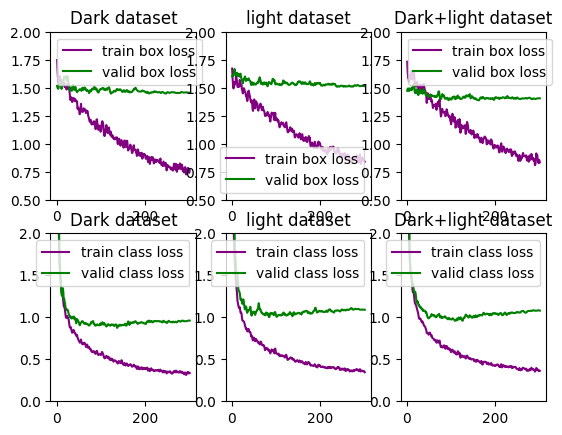

In [38]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics.utils.plotting import plot_results
from scipy.signal import savgol_filter, medfilt

csv_paths = [
    "runs/detect/train-14/results.csv",
    "runs/detect/train-15/results.csv",
    "runs/detect/train-18/results.csv"
]
titles = ["Dark dataset", "light dataset", "Dark+light dataset"]
fig, axs = plt.subplots(2, 3)

for i, csv_path in enumerate(csv_paths):

    df = pd.read_csv(csv_path)

    ax = axs[0, i]
    ax.plot(df["epoch"], savgol_filter(df["train/box_loss"], window_length=5, polyorder=2), color="purple")
    ax.plot(df["epoch"], savgol_filter(df["val/box_loss"], window_length=5, polyorder=2), color="green")
    ax.set_ylim([0.5, 2.0])
    ax.set_title(titles[i])
    ax.legend(["train box loss", "valid box loss"])
    #ax.plot(df["epoch"], medfilt(df["train/box_loss"], kernel_size=21))

    ax = axs[1, i]
    ax.plot(df["epoch"], savgol_filter(df["train/cls_loss"], window_length=5, polyorder=2), color="purple")
    ax.plot(df["epoch"], savgol_filter(df["val/cls_loss"], window_length=5, polyorder=2), color="green")
    ax.set_ylim([0.0, 2.0])
    ax.set_title(titles[i])
    ax.legend(["train class loss", "valid class loss"])


plt.show()
#plot_results(csv_path)